## Get EXIF Data From Videos

In [1]:
import os
import glob
from glob import glob
import pandas as pd
import subprocess
import logging
import matplotlib.pyplot as plt

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger('exif_extractor')

In [2]:
def find_files_recursively(directory, file_pattern):
    """
    Recursively find files matching a pattern in a directory and all subdirectories.
    
    Args:
        directory (str): Root directory to search
        file_pattern (str): Pattern to match files (e.g., '*.mp4')
        
    Returns:
        list: List of matching file paths
    """
    if file_pattern.startswith('*.'):
        extension = file_pattern[2:]
        file_list = []
        for root, _, _ in os.walk(directory):
            for ext in [extension.lower(), extension.upper()]:
                pattern = os.path.join(root, f"*.{ext}")
                file_list.extend(glob(pattern))
    else:
        file_list = []
        for root, _, _ in os.walk(directory):
            pattern = os.path.join(root, file_pattern)
            file_list.extend(glob(pattern))
            
    return file_list

def extract_exif_to_df(files=None, directory=".", file_pattern="*.mp4", output_dir=None, 
                      extract_gps=True, log_level=logging.INFO, recursive=True, 
                      skip_processed=True, processed_list_file=None):
    """
    Extracts EXIF metadata including time-series GPS data from GoPro videos.
    
    Args:
        files (list): Optional specific files to process.
        directory (str): Directory to search for files if files not specified.
        file_pattern (str): Pattern to match files (e.g., '*.mp4').
        output_dir (str): Directory for output files (defaults to input directory).
        extract_gps (bool): Whether to extract and parse GPS data specifically.
        log_level (int): Logging level.
        recursive (bool): Whether to search subdirectories recursively.
        skip_processed (bool): Whether to skip files that have already been processed.
        processed_list_file (str): Path to file that stores list of processed files.
        
    Returns:
        pd.DataFrame: DataFrame with extracted metadata.
        pd.DataFrame: DataFrame with GPS data if extract_gps is True.
    """
    logger = logging.getLogger(__name__)
    logger.setLevel(log_level)
    
    # Set output directory
    if output_dir is None:
        output_dir = directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize or load processed files list
    processed_files = set()
    if skip_processed:
        if processed_list_file is None:
            processed_list_file = os.path.join(output_dir, "processed_files.txt")
        
        # Load existing processed files list if it exists
        if os.path.exists(processed_list_file):
            with open(processed_list_file, 'r') as f:
                processed_files = set([line.strip() for line in f.readlines()])
            logger.info(f"Loaded {len(processed_files)} previously processed files from {processed_list_file}")
    
    # Get files to process
    if files:
        # Use provided files list
        file_list = files
        logger.info(f"Found {len(file_list)} specified files")
    else:
        # Handle recursive file search if requested
        if recursive:
            file_list = find_files_recursively(directory, file_pattern)
            logger.info(f"Found {len(file_list)} files matching pattern '{file_pattern}' recursively in '{directory}'")
        else:
            # Handle case-insensitive file matching (non-recursive)
            if file_pattern.startswith('*.'):
                extension = file_pattern[2:]
                file_list = []
                for ext in [extension.lower(), extension.upper()]:
                    file_list.extend(glob(os.path.join(directory, f"*.{ext}")))
            else:
                file_list = glob(os.path.join(directory, file_pattern))
            
            logger.info(f"Found {len(file_list)} files matching pattern '{file_pattern}' in '{directory}'")
    
    # Filter out already processed files if needed
    if skip_processed and processed_files:
        original_count = len(file_list)
        file_list = [f for f in file_list if os.path.abspath(f) not in processed_files]
        logger.info(f"Filtered out {original_count - len(file_list)} already processed files. {len(file_list)} files remaining to process.")
    
    if not file_list:
        logger.warning(f"No files found to process")
        # Return an empty DataFrame with the expected columns to prevent KeyError
        return pd.DataFrame(columns=['filename', 'filepath', 'filesize_bytes', 'filesize_mb', 
                                    'creation_time', 'modification_time', 'has_exif']), pd.DataFrame() if extract_gps else None
    
    all_rows = []
    gps_data_rows = []
    newly_processed_files = set()
    
    for file in file_list:
        abs_file_path = os.path.abspath(file)
        logger.info(f"Processing file: {file}")
        
        # Create relative path from input directory to maintain folder structure
        rel_path = os.path.relpath(os.path.dirname(abs_file_path), os.path.abspath(directory))
        
        # Create the same directory structure in output_dir
        file_output_dir = os.path.join(output_dir, rel_path)
        os.makedirs(file_output_dir, exist_ok=True)
        
        file_info = {
            "filename": os.path.basename(file),
            "filepath": abs_file_path,
            "filesize_bytes": os.path.getsize(file),
            "filesize_mb": os.path.getsize(file) / (1024 * 1024),
            "creation_time": pd.Timestamp(os.stat(file).st_ctime, unit='s'),
            "modification_time": pd.Timestamp(os.stat(file).st_mtime, unit='s'),
            "has_exif": True
        }
        
        try:
            # Run exiftool with enhanced GPS extraction
            cmd = ["exiftool", "-G", "-ee", "-api", "LargeFileSupport=1", file]
            result = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
            
            # Save raw output to text file for inspection with preserved folder structure
            output_file = os.path.join(file_output_dir, f"{os.path.splitext(os.path.basename(file))[0]}_exif.txt")
            with open(output_file, 'w') as f:
                f.write(result.stdout)
            logger.info(f"Saved raw EXIF data to {output_file}")
            
            # Parse the basic metadata
            row = file_info.copy()
            metadata = {}
            
            # For GPS data extraction
            current_gps_record = None
            gps_records = []
            
            lines = result.stdout.strip().split("\n")
            for line in lines:
                if ": " not in line:
                    continue
                
                tag_part, value = line.split(": ", 1)
                tag = tag_part.strip()
                
                # Clean tag name - extract section as prefix
                section = None
                for prefix in ["[GoPro]", "[QuickTime]", "[File]", "[Composite]", "[ExifTool]"]:
                    if tag.startswith(prefix):
                        section = prefix.strip("[]")
                        tag = tag[len(prefix):].strip()
                        break
                
                # If no section found, use "Other"
                if section is None:
                    section = "Other"
                
                # Skip binary data entries
                if "(Binary data" in value:
                    continue
                
                # Add section prefix to avoid column name collisions
                column_name = f"{section}_{tag}"
                
                # Extract GPS data into separate structure
                if extract_gps and section == "GoPro" and "GPS" in tag:
                    # Handle GPS data
                    if tag == "GPS Latitude" and value:
                        # Start new GPS record if needed
                        if current_gps_record is None or "latitude" in current_gps_record:
                            current_gps_record = {"filename": file_info["filename"]}
                        current_gps_record["latitude"] = value
                    elif tag == "GPS Longitude" and value:
                        if current_gps_record is not None:
                            current_gps_record["longitude"] = value
                    elif tag == "GPS Altitude" and value:
                        if current_gps_record is not None:
                            current_gps_record["altitude"] = value.split()[0]  # Strip units
                    elif tag == "GPS Speed" and value:
                        if current_gps_record is not None:
                            current_gps_record["speed"] = value
                    elif tag == "GPS Date Time" and value:
                        if current_gps_record is not None:
                            current_gps_record["timestamp"] = value
                            # Save complete GPS record and start fresh
                            if all(k in current_gps_record for k in ["latitude", "longitude", "timestamp"]):
                                gps_records.append(current_gps_record.copy())
                                current_gps_record = None
                
                # Add to metadata dictionary
                metadata[column_name] = value
            
            # Add all metadata to row
            row.update(metadata)
            all_rows.append(row)
            
            # Process GPS data into the DataFrame
            if extract_gps and gps_records:
                for record in gps_records:
                    gps_data_rows.append(record)
            
            # Mark this file as processed
            newly_processed_files.add(abs_file_path)
            
        except subprocess.TimeoutExpired:
            logger.error(f"Timeout while processing '{file}'")
            file_info["has_exif"] = False
            all_rows.append(file_info)
        except Exception as e:
            logger.error(f"Error processing '{file}': {str(e)}")
            file_info["has_exif"] = False
            all_rows.append(file_info)
    
    # Update the processed files list
    if skip_processed and newly_processed_files:
        processed_files.update(newly_processed_files)
        with open(processed_list_file, 'w') as f:
            for file_path in processed_files:
                f.write(f"{file_path}\n")
        logger.info(f"Updated processed files list with {len(newly_processed_files)} new files. Total: {len(processed_files)}")
    
    # Create metadata DataFrame
    if all_rows:
        # Ensure all rows have the same keys by filling missing keys with None
        all_keys = set()
        for row in all_rows:
            all_keys.update(row.keys())
        
        for row in all_rows:
            for key in all_keys:
                if key not in row:
                    row[key] = None
        
        # Now create the DataFrame with complete rows
        result_df = pd.DataFrame(all_rows)
        logger.info(f"Processed {len(file_list)} files. Created {len(result_df)} rows.")
        logger.info(f"Raw EXIF data saved to '{output_dir}' directory with preserved folder structure")
    else:
        # Return an empty DataFrame with the expected columns to prevent KeyError
        logger.warning("No metadata could be extracted from any files.")
        result_df = pd.DataFrame(columns=['filename', 'filepath', 'filesize_bytes', 'filesize_mb', 
                                         'creation_time', 'modification_time', 'has_exif'])
    
    # Create GPS DataFrame for current batch
    new_gps_df = pd.DataFrame()
    if extract_gps and gps_data_rows:
        new_gps_df = pd.DataFrame(gps_data_rows)
        logger.info(f"Extracted {len(new_gps_df)} new GPS data points.")
        
        # Handle GPS data - append to existing file if it exists
        gps_csv = os.path.join(output_dir, "gps_data.csv")
        if os.path.exists(gps_csv):
            # Check if file exists before trying to append
            try:
                # Load existing data to return combined DataFrame
                existing_gps_df = pd.read_csv(gps_csv)
                logger.info(f"Loaded {len(existing_gps_df)} existing GPS data points from {gps_csv}")
                
                # Append new data to the file without writing the header again
                new_gps_df.to_csv(gps_csv, mode='a', header=False, index=False)
                
                # Combine for the return value
                combined_gps_df = pd.concat([existing_gps_df, new_gps_df])
                logger.info(f"Appended {len(new_gps_df)} new GPS points to existing file. Total: {len(combined_gps_df)}")
                
                return result_df, combined_gps_df
            except Exception as e:
                logger.error(f"Error appending to existing GPS file: {str(e)}. Creating new file.")
                new_gps_df.to_csv(gps_csv, index=False)
                return result_df, new_gps_df
        else:
            # First time - create new file
            new_gps_df.to_csv(gps_csv, index=False)
            logger.info(f"Created new GPS data file with {len(new_gps_df)} points: {gps_csv}")
            return result_df, new_gps_df
    
    # If we get here with no new GPS data but the file exists, load and return existing GPS data
    if extract_gps:
        gps_csv = os.path.join(output_dir, "gps_data.csv")
        if os.path.exists(gps_csv):
            try:
                existing_gps_df = pd.read_csv(gps_csv)
                logger.info(f"No new GPS data extracted. Returning existing {len(existing_gps_df)} GPS points.")
                return result_df, existing_gps_df
            except Exception as e:
                logger.error(f"Error reading existing GPS file: {str(e)}. Returning empty DataFrame.")
        
        logger.warning("No GPS data found in the processed files.")
        return result_df, pd.DataFrame()
    else:
        return result_df, None

In [3]:
VIDEO_DIR = "../mumbai_vids/"
OUTPUT_DIR = "../mumbai_exif_out/" 
FILE_PATTERN = "*.mp4"

os.makedirs(OUTPUT_DIR, exist_ok=True)

metadata_df, gps_df = extract_exif_to_df(
    directory=VIDEO_DIR,
    file_pattern=FILE_PATTERN,
    output_dir=OUTPUT_DIR,
    extract_gps=True,
    log_level=logging.INFO
)

print(f"Extracted metadata from {len(metadata_df)} files")
print(f"Found {len(gps_df) if gps_df is not None else 0} GPS data points")

display(metadata_df[['filename', 'filesize_mb', 'has_exif']].sort_values('filename'))

2025-04-12 13:19:10 - INFO - Found 38 files matching pattern '*.mp4' recursively in '../mumbai_vids/'
2025-04-12 13:19:10 - INFO - Processing file: ../mumbai_vids/day2_3_29/itinerary_1_2.MP4
2025-04-12 13:19:12 - INFO - Saved raw EXIF data to ../mumbai_exif_out/day2_3_29/itinerary_1_2_exif.txt
2025-04-12 13:19:12 - INFO - Processing file: ../mumbai_vids/day2_3_29/itinerary_5_2.MP4
2025-04-12 13:19:16 - INFO - Saved raw EXIF data to ../mumbai_exif_out/day2_3_29/itinerary_5_2_exif.txt
2025-04-12 13:19:16 - INFO - Processing file: ../mumbai_vids/day2_3_29/dadar_flower_market.MP4
2025-04-12 13:19:23 - INFO - Saved raw EXIF data to ../mumbai_exif_out/day2_3_29/dadar_flower_market_exif.txt
2025-04-12 13:19:23 - INFO - Processing file: ../mumbai_vids/day2_3_29/itinerary_2_2.MP4
2025-04-12 13:19:24 - INFO - Saved raw EXIF data to ../mumbai_exif_out/day2_3_29/itinerary_2_2_exif.txt
2025-04-12 13:19:24 - INFO - Processing file: ../mumbai_vids/day1_3_27/itinerary_2_3.MP4
2025-04-12 13:19:26 - INF

Extracted metadata from 38 files
Found 256505 GPS data points


,filename,filesize_mb,has_exif
35,Test_drive_3.MP4,3838.372286,True
2,dadar_flower_market.MP4,3153.334291,True
32,gps_test_1.MP4,110.707814,True
33,gps_test_2.MP4,111.099422,True
34,gps_test_3.MP4,100.669154,True
19,itinerary_1.MP4,5507.482535,True
27,itinerary_1_1.MP4,11364.344454,True
8,itinerary_1_1.MP4,3233.901365,True
9,itinerary_1_2.MP4,2572.999847,True
28,itinerary_1_2.MP4,588.197151,True


In [4]:
gps_df

,filename,latitude,longitude,altitude,speed,timestamp
0,itinerary_1_2.MP4,"19 deg 1' 12.65"" N","72 deg 50' 3.07"" E",6.868,11.646,2025:03:29 03:19:51.700
1,itinerary_1_2.MP4,"19 deg 1' 12.64"" N","72 deg 50' 3.06"" E",6.906,10.7064,2025:03:29 03:19:51.800
2,itinerary_1_2.MP4,"19 deg 1' 12.63"" N","72 deg 50' 3.05"" E",7.034,10.8792,2025:03:29 03:19:51.900
3,itinerary_1_2.MP4,"19 deg 1' 12.63"" N","72 deg 50' 3.04"" E",7.211,11.1492,2025:03:29 03:19:52.000
4,itinerary_1_2.MP4,"19 deg 1' 12.62"" N","72 deg 50' 3.04"" E",7.027,11.1852,2025:03:29 03:19:52.100
...,...,...,...,...,...,...
256500,test_drive_7.MP4,"19 deg 4' 27.95"" N","72 deg 59' 56.51"" E",16.688,21.8952,2025:03:23 06:33:40.700
256501,test_drive_7.MP4,"19 deg 4' 27.95"" N","72 deg 59' 56.48"" E",15.598,24.102,2025:03:23 06:33:40.800
256502,test_drive_7.MP4,"19 deg 4' 27.95"" N","72 deg 59' 56.46"" E",14.756,22.7376,2025:03:23 06:33:40.900
256503,test_drive_7.MP4,"19 deg 4' 27.95"" N","72 deg 59' 56.44"" E",14.888,22.1472,2025:03:23 06:33:41.000


In [5]:
print(gps_df)

                 filename            latitude            longitude altitude  \
0       itinerary_1_2.MP4  19 deg 1' 12.65" N   72 deg 50' 3.07" E    6.868   
1       itinerary_1_2.MP4  19 deg 1' 12.64" N   72 deg 50' 3.06" E    6.906   
2       itinerary_1_2.MP4  19 deg 1' 12.63" N   72 deg 50' 3.05" E    7.034   
3       itinerary_1_2.MP4  19 deg 1' 12.63" N   72 deg 50' 3.04" E    7.211   
4       itinerary_1_2.MP4  19 deg 1' 12.62" N   72 deg 50' 3.04" E    7.027   
...                   ...                 ...                  ...      ...   
256500   test_drive_7.MP4  19 deg 4' 27.95" N  72 deg 59' 56.51" E   16.688   
256501   test_drive_7.MP4  19 deg 4' 27.95" N  72 deg 59' 56.48" E   15.598   
256502   test_drive_7.MP4  19 deg 4' 27.95" N  72 deg 59' 56.46" E   14.756   
256503   test_drive_7.MP4  19 deg 4' 27.95" N  72 deg 59' 56.44" E   14.888   
256504   test_drive_7.MP4  19 deg 4' 27.95" N  72 deg 59' 56.42" E   14.718   

          speed                timestamp  
0       

Step 1: Parsing GPS coordinate strings to decimal degrees...
Parsed coordinates for 256505 rows.
Time taken for Step 1: 0.93 sec

Step 2: Sampling points from gps_df...
Sampled 10000 points from 256505 total rows.
Time taken for Step 2: 0.01 sec

Step 3: Creating GeoDataFrame from sampled data...
GeoDataFrame created. Projecting to Web Mercator (EPSG:3857) for basemap compatibility...
Time taken for Step 3: 0.08 sec

Step 4: Plotting GPS points over Mumbai street map...
Basemap tiles loaded from OpenStreetMap.
Time taken for Step 4: 0.56 sec


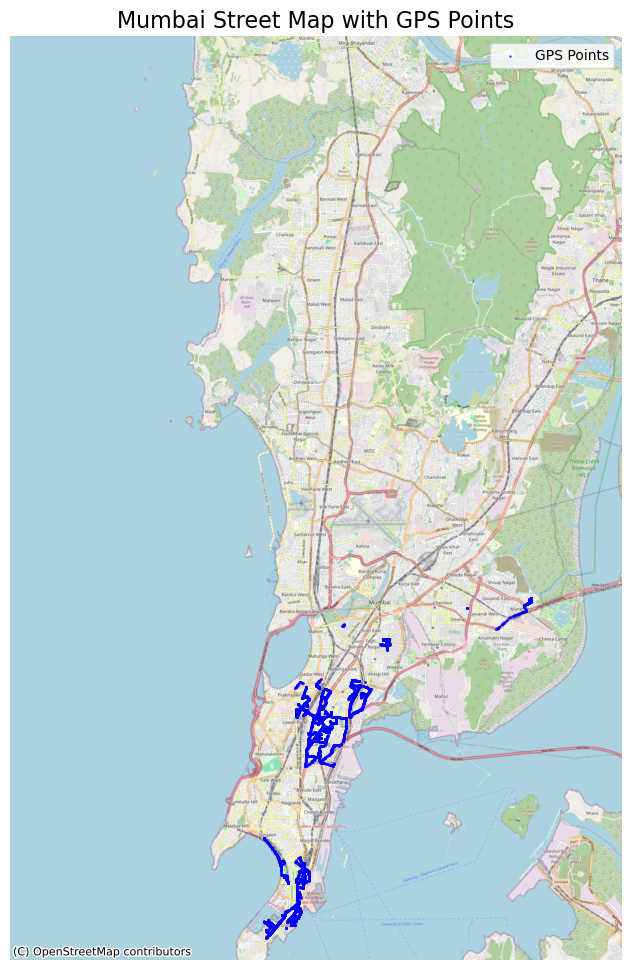

Plot saved as 'mumbai_gps_map.png'


<Figure size 640x480 with 0 Axes>

In [23]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import time

# ===============================
# Step 1: Parse GPS Coordinates
# ===============================
print("Step 1: Parsing GPS coordinate strings to decimal degrees...")
t0 = time.time()

def parse_coordinate(coord_str):
    """
    Convert a coordinate string like "19 deg 1' 12.65\" N" to a decimal degree.
    """
    # Updated regex: only valid directions (N, S, E, or W)
    regex = r"(\d+)\s*deg\s*(\d+)'[\s]*([\d.]+)\"[\s]*([NSEW])"
    match = re.search(regex, str(coord_str))
    if not match:
        print(f"Warning: Failed to parse coordinate: {coord_str}")
        return None
    degrees = float(match.group(1))
    minutes = float(match.group(2))
    seconds = float(match.group(3))
    direction = match.group(4)
    decimal = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        decimal = -decimal
    return decimal

# Apply coordinate parsing to the gps_df DataFrame
gps_df['lat_decimal'] = gps_df['latitude'].apply(parse_coordinate)
gps_df['lon_decimal'] = gps_df['longitude'].apply(parse_coordinate)

# Drop rows that failed to parse
gps_df = gps_df.dropna(subset=['lat_decimal', 'lon_decimal'])
print(f"Parsed coordinates for {len(gps_df)} rows.")
print(f"Time taken for Step 1: {time.time() - t0:.2f} sec\n")


# ======================================
# Step 2: Sample 10,000 Points (if needed)
# ======================================
print("Step 2: Sampling points from gps_df...")
t0 = time.time()
SAMPLE_SIZE = 10000
if len(gps_df) > SAMPLE_SIZE:
    sample_df = gps_df.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"Sampled {SAMPLE_SIZE} points from {len(gps_df)} total rows.")
else:
    sample_df = gps_df.copy()
    print(f"Using all {len(gps_df)} rows (total count below sample size).")
print(f"Time taken for Step 2: {time.time() - t0:.2f} sec\n")


# ===============================================
# Step 3: Create a GeoDataFrame and Project It
# ===============================================
print("Step 3: Creating GeoDataFrame from sampled data...")
t0 = time.time()
geometry = [Point(lon, lat) for lon, lat in zip(sample_df['lon_decimal'], sample_df['lat_decimal'])]
geo_df = gpd.GeoDataFrame(sample_df, geometry=geometry, crs="EPSG:4326")
print("GeoDataFrame created. Projecting to Web Mercator (EPSG:3857) for basemap compatibility...")
geo_df_projected = geo_df.to_crs(epsg=3857)
print(f"Time taken for Step 3: {time.time() - t0:.2f} sec\n")


# ===============================================
# Step 4: Plot the GPS Points on the Mumbai Map
# ===============================================
import pyproj

print("Step 4: Plotting GPS points over Mumbai street map...")
t0 = time.time()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot the GPS points with smaller markers and increased transparency.
# Adjust markersize and alpha as desired (here, markersize=1 and alpha=0.5).
geo_df_projected.plot(
    ax=ax,
    color='blue',
    markersize=1,   # Reduced marker size; adjust to your taste.
    alpha=0.5,      # Increased transparency to reveal overlapping density.
    label='GPS Points'
)

# Instead of using the total bounds, we fix the bounding box for Mumbai.
projector = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
minx, miny = projector.transform(72.7, 18.9)
maxx, maxy = projector.transform(72.98, 19.3)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13)
    print("Basemap tiles loaded from OpenStreetMap.")
except Exception as e:
    print(f"Error loading basemap: {e}\nMake sure contextily is installed and working.")

ax.set_title("Mumbai Street Map with GPS Points", fontsize=16)
ax.legend()
ax.set_axis_off()

print(f"Time taken for Step 4: {time.time() - t0:.2f} sec")
plt.show()

plt.savefig('mumbai_gps_map.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'mumbai_gps_map.png'")